In [1]:
%matplotlib inline

# Лабораторная работа №5. Методы принятия решений в сложных системах

**Дисциплина:** Теория систем · **Вариант 2** (выбор СУБД для социальной сети)

Социальная сеть на 10 млн активных пользователей. Требования: высокая
скорость чтения ленты, поток операций записи (лайки, комментарии),
горизонтальное масштабирование, транзакционная целостность для
лайков и комментариев. Нужно выбрать СУБД из четырёх альтернатив
по пяти независимым критериям двумя методами (WSM и МАИ),
затем проверить устойчивость выбора анализом чувствительности.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "font.size": 11})

from pathlib import Path
FIG = Path(__file__).resolve().parent / "figures" if "__file__" in globals() else Path("figures")
FIG.mkdir(parents=True, exist_ok=True)

ALT = ["PostgreSQL", "MongoDB", "Cassandra", "CockroachDB"]
CRIT = ["K1 чтение", "K2 запись", "K3 масштаб", "K4 целостн.", "K5 TCO"]

## Альтернативы и критерии

- **A1 PostgreSQL** — реляционная, строгий ACID, вертикальное масштабирование.
- **A2 MongoDB** — документная, нативный шардинг, гибкая схема.
- **A3 Cassandra** — wide-column, masterless, рекордная запись, eventual consistency.
- **A4 CockroachDB** — distributed SQL (NewSQL), ACID + горизонтальное масштабирование.

Критерии:
- **K1** задержка чтения, мс (min)
- **K2** пропускная способность записи, тыс. оп/с (max)
- **K3** горизонтальная масштабируемость, балл 1-10 (max)
- **K4** транзакционная целостность, балл 1-10 (max)
- **K5** совокупная стоимость и сложность администрирования, балл 1-10 (min)

In [3]:
# Таблица исходных данных
raw = np.array([
    # K1   K2    K3   K4   K5
    [2.0,  15.0, 4.0, 10.0, 3.0],   # PostgreSQL
    [5.0,  40.0, 8.0,  6.0, 5.0],   # MongoDB
    [8.0, 120.0, 10.0, 4.0, 8.0],   # Cassandra
    [6.0,  35.0, 9.0,  9.0, 7.0],   # CockroachDB
])
is_max = np.array([False, True, True, True, False])  # тип критерия
df_raw = pd.DataFrame(raw, index=ALT, columns=CRIT)
print("Исходные данные:\n", df_raw, "\n")

Исходные данные:
              K1 чтение  K2 запись  K3 масштаб  K4 целостн.  K5 TCO
PostgreSQL         2.0       15.0         4.0         10.0     3.0
MongoDB            5.0       40.0         8.0          6.0     5.0
Cassandra          8.0      120.0        10.0          4.0     8.0
CockroachDB        6.0       35.0         9.0          9.0     7.0 



## Шаг 1. Нормализация (min-max, формулы 3 и 4)

In [4]:
def normalize(col, maximize):
    lo, hi = col.min(), col.max()
    if maximize:
        return (col - lo) / (hi - lo)
    return (hi - col) / (hi - lo)

norm = np.column_stack([normalize(raw[:, j], is_max[j]) for j in range(raw.shape[1])])
df_norm = pd.DataFrame(norm, index=ALT, columns=CRIT)
print("Нормализованная матрица (1 = лучшее):\n", df_norm.round(3), "\n")

Нормализованная матрица (1 = лучшее):
              K1 чтение  K2 запись  K3 масштаб  K4 целостн.  K5 TCO
PostgreSQL       1.000      0.000       0.000        1.000     1.0
MongoDB          0.500      0.238       0.667        0.333     0.6
Cassandra        0.000      1.000       1.000        0.000     0.0
CockroachDB      0.333      0.190       0.833        0.833     0.2 



## Шаг 2. Метод взвешенных сумм (WSM)

In [5]:
w_wsm = np.array([0.25, 0.20, 0.25, 0.15, 0.15])
assert abs(w_wsm.sum() - 1) < 1e-9
S = norm @ w_wsm
wsm = pd.Series(S, index=ALT).sort_values(ascending=False)
print("Веса WSM:", dict(zip(CRIT, w_wsm)))
print("\nИтоговые оценки WSM (по убыванию):\n", wsm.round(4))
print("\nЛидер WSM:", wsm.index[0])

Веса WSM: {'K1 чтение': np.float64(0.25), 'K2 запись': np.float64(0.2), 'K3 масштаб': np.float64(0.25), 'K4 целостн.': np.float64(0.15), 'K5 TCO': np.float64(0.15)}

Итоговые оценки WSM (по убыванию):
 PostgreSQL     0.5500
CockroachDB    0.4848
MongoDB        0.4793
Cassandra      0.4500
dtype: float64

Лидер WSM: PostgreSQL


## Шаг 3. Метод анализа иерархий (МАИ)

### 3.1 Матрица попарных сравнений критериев (шкала Саати 1-9)

In [6]:
def ahp_weights(M):
    """Главный собственный вектор + lambda_max + ИС + ОС."""
    vals, vecs = np.linalg.eig(M)
    k = np.argmax(vals.real)
    w = np.abs(vecs[:, k].real)
    w = w / w.sum()
    lam = vals[k].real
    n = M.shape[0]
    CI = (lam - n) / (n - 1)
    RI = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32}[n]
    CR = CI / RI if RI else 0.0
    return w, lam, CI, CR

def geomean_weights(M):
    g = np.prod(M, axis=1) ** (1 / M.shape[0])
    return g / g.sum()

# Экспертная матрица сравнения критериев (важность для соцсети 10M)
Mc = np.array([
    [1,   2,   1,   2,   3  ],   # K1 чтение
    [1/2, 1,   1/2, 1,   2  ],   # K2 запись
    [1,   2,   1,   2,   3  ],   # K3 масштаб
    [1/2, 1,   1/2, 1,   1  ],   # K4 целостность
    [1/3, 1/2, 1/3, 1,   1  ],   # K5 TCO
])
wc, lam_c, CI_c, CR_c = ahp_weights(Mc)
wc_g = geomean_weights(Mc)
print("Веса критериев (собств. вектор):", dict(zip(CRIT, wc.round(4))))
print("Веса критериев (геом. среднее): ", wc_g.round(4))
print(f"lambda_max = {lam_c:.4f}, ИС = {CI_c:.4f}, ОС = {CR_c*100:.2f}%  (< 10% -> {'OK' if CR_c<0.1 else 'ПЕРЕСМОТР'})")

Веса критериев (собств. вектор): {'K1 чтение': np.float64(0.2988), 'K2 запись': np.float64(0.1597), 'K3 масштаб': np.float64(0.2988), 'K4 целостн.': np.float64(0.1391), 'K5 TCO': np.float64(0.1035)}
Веса критериев (геом. среднее):  [0.3001 0.1589 0.3001 0.1384 0.1024]
lambda_max = 5.0394, ИС = 0.0098, ОС = 0.88%  (< 10% -> OK)


### 3.2 Попарные сравнения альтернатив по каждому критерию

Матрицы строятся автоматически из исходных данных: значения каждого
критерия переводятся в шкалу полезности 1-10 (для min-критериев
направление инвертируется), затем разрыв полезностей округляется до
целой оценки Саати. Это делает суждения воспроизводимыми и почти
транзитивными, поэтому ОС каждой матрицы мал.

In [7]:
def utility(col, maximize):
    lo, hi = col.min(), col.max()
    base = (col - lo) if maximize else (hi - col)
    return 1 + 9 * base / (hi - lo)

def saaty(ratio):
    # ratio >= 1; ближайшая целая оценка шкалы Саати 1..9
    return min(max(int(round(ratio)), 1), 9)

def pairwise(u):
    # мультипликативная шкала: a_ij ~ u_i/u_j, округлённое к целым Саати.
    # Матрица почти идеально согласована (несогласованность только от округления).
    n = len(u)
    M = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if u[i] >= u[j]:
                M[i, j] = saaty(u[i] / u[j])
            else:
                M[i, j] = 1 / saaty(u[j] / u[i])
    return M

local = np.zeros((len(ALT), len(CRIT)))
ahp_diag = []
mats = {}
for j in range(len(CRIT)):
    u = utility(raw[:, j], is_max[j])
    M = pairwise(u)
    mats[CRIT[j]] = M
    w, lam, CI, CR = ahp_weights(M)
    local[:, j] = w
    ahp_diag.append((CRIT[j], lam, CI, CR))
    print(f"\n{CRIT[j]}: полезности {u.round(2)}")
    print(f"   локальные приоритеты {dict(zip(ALT, w.round(4)))}")
    print(f"   lambda_max={lam:.4f}  ОС={CR*100:.2f}%  {'OK' if CR<0.1 else 'ПЕРЕСМОТР'}")

df_local = pd.DataFrame(local, index=ALT, columns=CRIT)
print("\nЛокальные приоритеты альтернатив:\n", df_local.round(4))


K1 чтение: полезности [10.   5.5  1.   4. ]
   локальные приоритеты {'PostgreSQL': np.float64(0.4687), 'MongoDB': np.float64(0.2531), 'Cassandra': np.float64(0.0502), 'CockroachDB': np.float64(0.2281)}
   lambda_max=4.0164  ОС=0.61%  OK

K2 запись: полезности [ 1.    3.14 10.    2.71]
   локальные приоритеты {'PostgreSQL': np.float64(0.0606), 'MongoDB': np.float64(0.1819), 'Cassandra': np.float64(0.5879), 'CockroachDB': np.float64(0.1696)}
   lambda_max=4.0104  ОС=0.38%  OK

K3 масштаб: полезности [ 1.   7.  10.   8.5]
   локальные приоритеты {'PostgreSQL': np.float64(0.0402), 'MongoDB': np.float64(0.3099), 'Cassandra': np.float64(0.33), 'CockroachDB': np.float64(0.3199)}
   lambda_max=4.0059  ОС=0.22%  OK

K4 целостн.: полезности [10.   4.   1.   8.5]
   локальные приоритеты {'PostgreSQL': np.float64(0.3885), 'MongoDB': np.float64(0.1886), 'Cassandra': np.float64(0.0458), 'CockroachDB': np.float64(0.3771)}
   lambda_max=4.0017  ОС=0.06%  OK

K5 TCO: полезности [10.   6.4  1.   2.8]
 

### 3.3 Глобальные приоритеты

In [8]:
P = local @ wc
ahp = pd.Series(P, index=ALT).sort_values(ascending=False)
print("Глобальные приоритеты МАИ (по убыванию):\n", ahp.round(4))
print("Сумма =", P.sum().round(6))
print("Лидер МАИ:", ahp.index[0])

# Сводка согласованности всех 6 матриц
print("\nСогласованность всех матриц:")
print(f"  критериев: ОС = {CR_c*100:.2f}%")
for name, lam, CI, CR in ahp_diag:
    print(f"  {name}: ОС = {CR*100:.2f}%")

Глобальные приоритеты МАИ (по убыванию):
 PostgreSQL     0.2703
CockroachDB    0.2579
MongoDB        0.2527
Cassandra      0.2191
dtype: float64
Сумма = 1.0
Лидер МАИ: PostgreSQL

Согласованность всех матриц:
  критериев: ОС = 0.88%
  K1 чтение: ОС = 0.61%
  K2 запись: ОС = 0.38%
  K3 масштаб: ОС = 0.22%
  K4 целостн.: ОС = 0.06%
  K5 TCO: ОС = 0.38%


## Шаг 4. Анализ чувствительности (WSM)

In [9]:
def scenario(weights):
    w = np.array(weights, float)
    w = w / w.sum()
    s = norm @ w
    return pd.Series(s, index=ALT)

scen = {
    "Базовый":          w_wsm,
    "C1 чтение 0,5":    [0.50, 0.125, 0.125, 0.125, 0.125],
    "C2 масштаб 0,5":   [0.125, 0.125, 0.50, 0.125, 0.125],
    "C3 целостн. 0,5":  [0.125, 0.125, 0.125, 0.50, 0.125],
    "C4 стоимость 0,5": [0.125, 0.125, 0.125, 0.125, 0.50],
}
sens = pd.DataFrame({k: scenario(v) for k, v in scen.items()})
print("Матрица чувствительности (оценки WSM):\n", sens.round(3))
print("\nЛидеры по сценариям:")
for c in sens.columns:
    print(f"  {c}: {sens[c].idxmax()}  ({sens[c].max():.3f})")

Матрица чувствительности (оценки WSM):
              Базовый  C1 чтение 0,5  C2 масштаб 0,5  C3 целостн. 0,5  \
PostgreSQL     0.550          0.750           0.375            0.750   
MongoDB        0.479          0.480           0.542            0.417   
Cassandra      0.450          0.250           0.625            0.250   
CockroachDB    0.485          0.424           0.611            0.611   

             C4 стоимость 0,5  
PostgreSQL              0.750  
MongoDB                 0.517  
Cassandra               0.250  
CockroachDB             0.374  

Лидеры по сценариям:
  Базовый: PostgreSQL  (0.550)
  C1 чтение 0,5: PostgreSQL  (0.750)
  C2 масштаб 0,5: Cassandra  (0.625)
  C3 целостн. 0,5: PostgreSQL  (0.750)
  C4 стоимость 0,5: PostgreSQL  (0.750)


## Графики

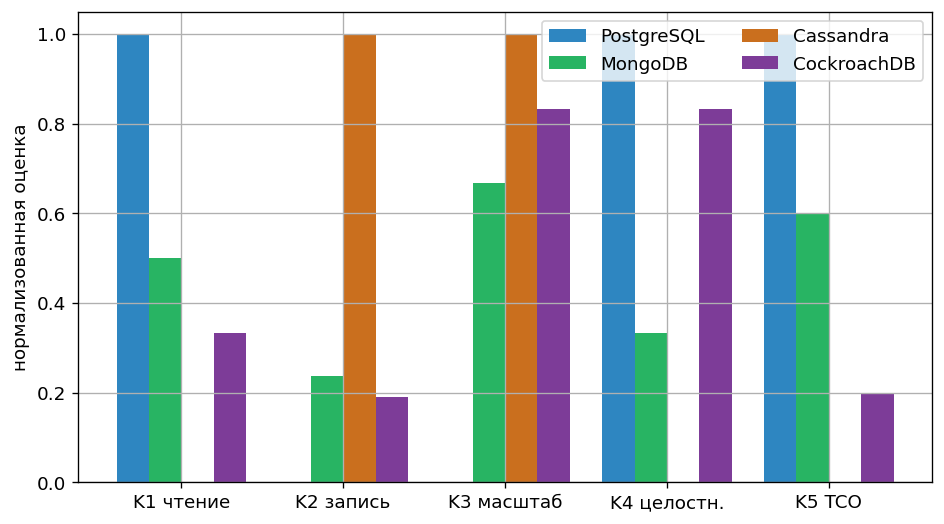

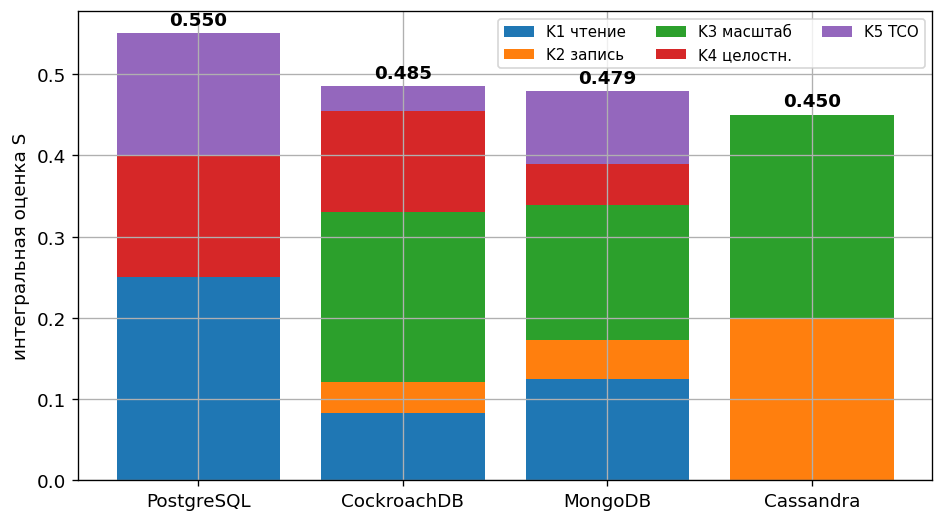

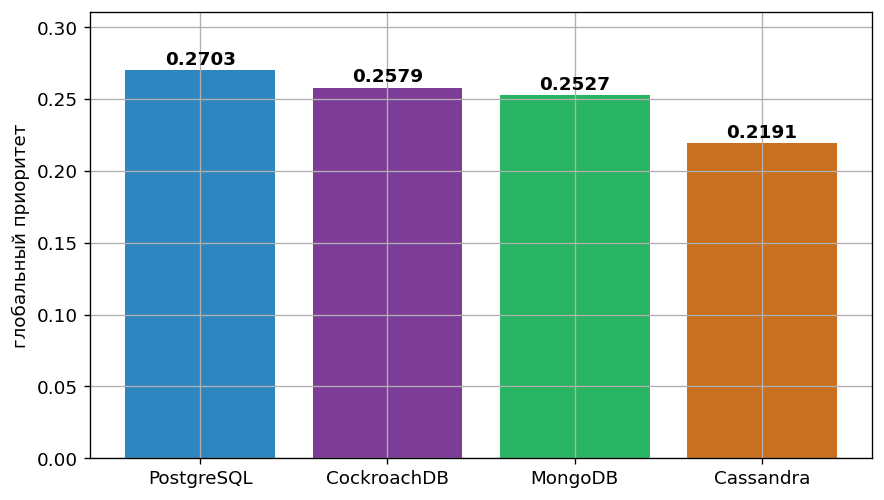

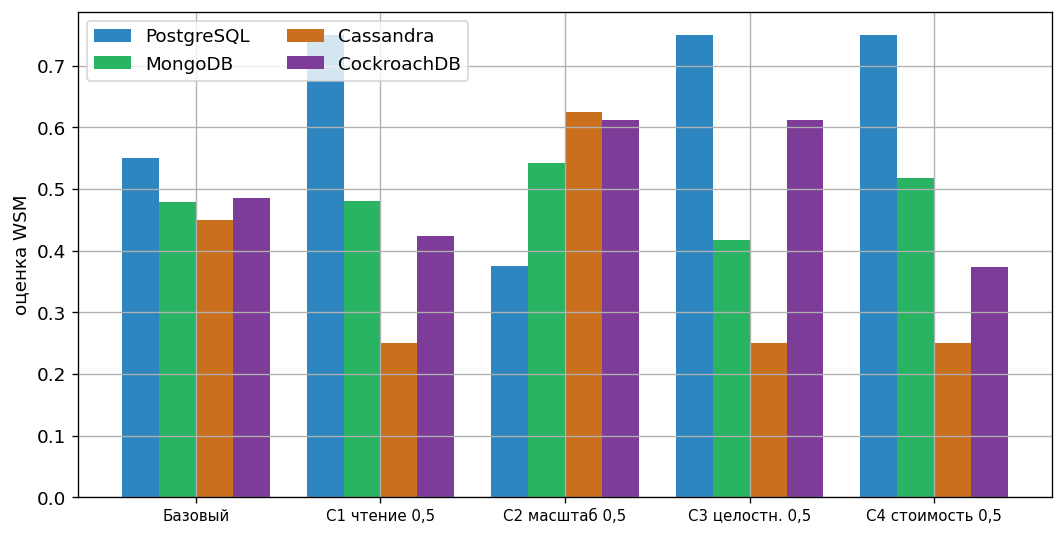

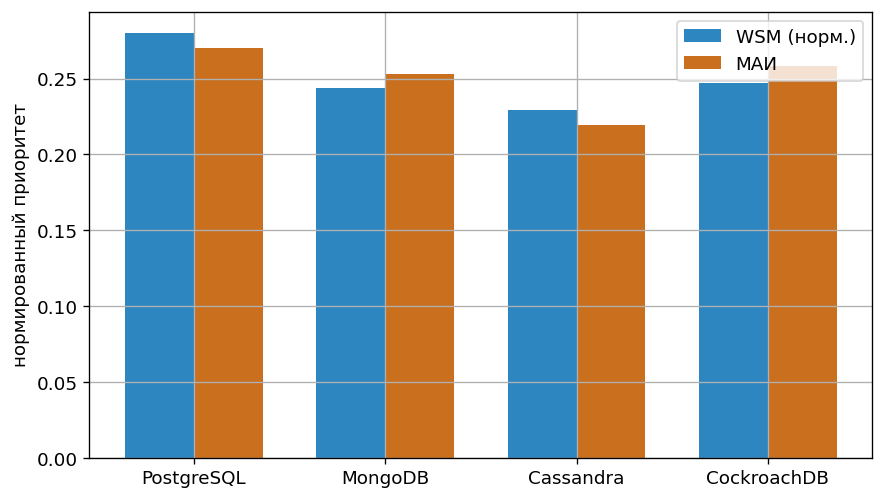

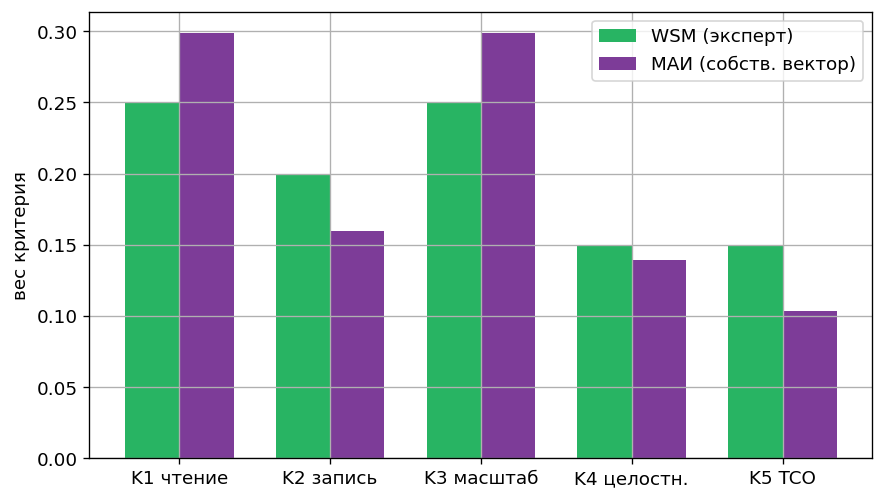

In [10]:
colors = ["#2E86C1", "#28B463", "#CA6F1E", "#7D3C98"]

# 1. Нормализованные значения по критериям (grouped bar)
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(CRIT)); bw = 0.2
for i, a in enumerate(ALT):
    ax.bar(x + (i - 1.5) * bw, norm[i], bw, label=a, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(CRIT)
ax.set_ylabel("нормализованная оценка"); ax.legend(ncol=2)
plt.tight_layout(); plt.savefig(FIG / "normalized.png"); plt.show()

# 2. WSM stacked по вкладам критериев
fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = np.zeros(len(ALT))
contrib = norm * w_wsm
order = np.argsort(-S)
for j in range(len(CRIT)):
    ax.bar(np.array(ALT)[order], contrib[order, j], bottom=bottom[order], label=CRIT[j])
    bottom += contrib[:, j]
for r, a in enumerate(np.array(ALT)[order]):
    ax.text(r, S[order][r] + 0.01, f"{S[order][r]:.3f}", ha="center", fontweight="bold")
ax.set_ylabel("интегральная оценка S"); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "wsm.png"); plt.show()

# 3. МАИ глобальные приоритеты
fig, ax = plt.subplots(figsize=(7.5, 4.3))
o = np.argsort(-P)
bars = ax.bar(np.array(ALT)[o], P[o], color=[colors[i] for i in o])
for b, val in zip(bars, P[o]):
    ax.text(b.get_x() + b.get_width()/2, val + 0.004, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylabel("глобальный приоритет"); ax.set_ylim(0, max(P)*1.15)
plt.tight_layout(); plt.savefig(FIG / "ahp.png"); plt.show()

# 4. Чувствительность (grouped bar)
fig, ax = plt.subplots(figsize=(9, 4.6))
xs = np.arange(len(sens.columns)); bw = 0.2
for i, a in enumerate(ALT):
    ax.bar(xs + (i - 1.5) * bw, sens.loc[a], bw, label=a, color=colors[i])
ax.set_xticks(xs); ax.set_xticklabels(sens.columns, fontsize=9)
ax.set_ylabel("оценка WSM"); ax.legend(ncol=2)
plt.tight_layout(); plt.savefig(FIG / "sensitivity.png"); plt.show()

# 5. Сравнение WSM и МАИ (нормированные к сумме=1)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
S_n = S / S.sum()
xs = np.arange(len(ALT)); bw = 0.36
ax.bar(xs - bw/2, S_n, bw, label="WSM (норм.)", color="#2E86C1")
ax.bar(xs + bw/2, P, bw, label="МАИ", color="#CA6F1E")
ax.set_xticks(xs); ax.set_xticklabels(ALT)
ax.set_ylabel("нормированный приоритет"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "compare.png"); plt.show()

# 6. Веса критериев WSM vs МАИ
fig, ax = plt.subplots(figsize=(7.5, 4.3))
xs = np.arange(len(CRIT)); bw = 0.36
ax.bar(xs - bw/2, w_wsm, bw, label="WSM (эксперт)", color="#28B463")
ax.bar(xs + bw/2, wc, bw, label="МАИ (собств. вектор)", color="#7D3C98")
ax.set_xticks(xs); ax.set_xticklabels(CRIT)
ax.set_ylabel("вес критерия"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "weights.png"); plt.show()